# Quick start

This notebook is a short illustration of how the `pgam_jax.GAM` class can be fit to a combination of spatial and temporal responses.

It closely follows the [original PGAM implementation's tutorial](https://github.com/BalzaniEdoardo/PGAM/blob/main/PGAM_Tutorial.ipynb), showing how `nemos` and `pgam_jax` can be used for the same purpose.

For more background, please refer to that tutorial, as well as the NeMoS docs about [bases](https://nemos.readthedocs.io/en/latest/background/basis/README.html) and [convolution](https://nemos.readthedocs.io/en/latest/background/plot_03_1D_convolution.html).

## Imports

In [1]:
import jax
import matplotlib.pyplot as plt
import nemos as nmo
import numpy as np
import pynapple as nap
import scipy.stats as sts
import seaborn as sns

jax.config.update("jax_enable_x64", True)
sns.set_theme(style="whitegrid")

In [2]:
rng = np.random.default_rng(123)

## Convolutional bases for temporal responses

For modeling responses to temporal events, such as incoming spikes or current injections, `nemos` provides convolutional bases.

These can be used to assemble temporal filters from basis components based on the data.

Convolutional filters are causal by default:

[Text(0.5, 0, 'time points'), Text(0.5, 1.0, 'convolved events')]

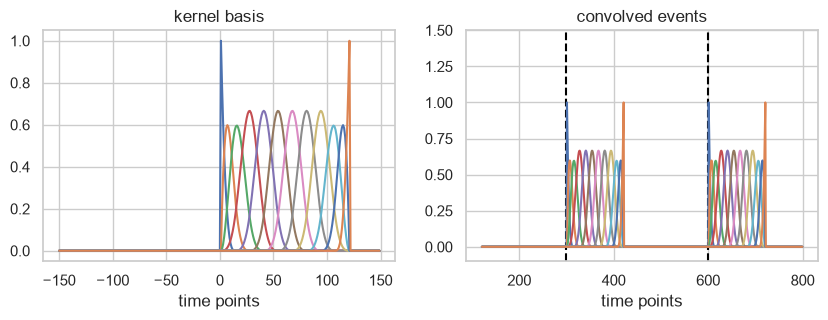

In [3]:
n_tp = 800

plot_events = np.zeros(n_tp)
plot_events[300] = 1
plot_events[600] = 1

basis = nmo.basis.BSplineConv(12, window_size=121)

fig, ax = plt.subplots(figsize=(10, 3), ncols=2)

ax[0].plot(np.arange(-150, 150), basis.compute_features(plot_events)[150:450])

ax[1].axvline(300, ls="--", color="black")
ax[1].axvline(600, ls="--", color="black")
ax[1].plot(basis.compute_features(plot_events))
ax[1].set_ylim(-0.1, 1.5)

ax[0].set(xlabel="time points", title="kernel basis")
ax[1].set(xlabel="time points", title="convolved events")

## Generate synthetic data

We will simulate spiking responses that depend on three kinds of inputs:
- a spatial variable, which directly affects the firing rate
- a nuisance variable, which has no effect and should ideally be ignored by the model
- a temporal variable, here a set of events, which affects the firing rate for some time after each event

The firing rate is generated from an additive model on the log scale

$$
\log \mu(t)
=
f_{\mathrm{spatial}}\!\left(x_{\mathrm{spatial}}(t)\right)
+
f_{\mathrm{temporal}}\!\left(x_{\mathrm{temporal}}\right)(t)
$$

Spike counts are then sampled from a Poisson distribution
$$
y(t) \sim \mathrm{Poisson}(\mu(t))
$$

Here, $f_{\mathrm{spatial}}$ and $f_{\mathrm{temporal}}$ are the effects that we will try to recover by fitting the model later.

The spatial effect is a direct map from the spatial variable to the firing rate. The temporal effect is generated by convolving the event train with a response kernel, so each event can influence firing rates over a short window of time
  
In the context of GAMs, these effects are commonly called *smooths*.

In [4]:
time_bin = 0.006
n_time_points = int(30 * 60 / time_bin)  # 30 mins at 6 ms resolution
num_events = 6000  # number of temporal input events
rate = 5 * time_bin  # expected spike count per bin
variance = 5.0  # spatial input and nuisance variance
order = 4  # spline order for spatial variable

n_trials = 200
assert n_time_points % n_trials == 0, "n_time_points must divide evenly into n_trials"
trial_length = n_time_points // n_trials
trial_ids = np.repeat(np.arange(n_trials), trial_length)

# we currently don't use separate test and train trials
## split trial in train and eval
# train_trials = trial_ids % 10 != 0
# eval_trials = ~train_trials

Create temporal input

In [5]:
idx = rng.choice(np.arange(n_time_points), num_events, replace=False)
events = np.zeros(n_time_points)
events[idx] = 1

Create spatial and nuisance inputs

In [6]:
rv = sts.multivariate_normal(mean=[0, 0], cov=variance * np.eye(2))
samp = rv.rvs(n_time_points, random_state=rng)
spatial_var = samp[:, 0]
nuisance_var = samp[:, 1]

# truncate X to avoid jumps in the resp function
# so bring all samples into [-5, 5]

sele_idx = np.abs(spatial_var) < 5
spatial_var = spatial_var[sele_idx]
nuisance_var = nuisance_var[sele_idx]

# add data that is (-5, 5) until we fill all the time points
while spatial_var.shape[0] < n_time_points:
    tmpX = rv.rvs(10**4, random_state=rng)
    sele_idx = np.abs(tmpX[:, 0]) < 5
    tmpX = tmpX[sele_idx, :]

    spatial_var = np.hstack((spatial_var, tmpX[:, 0]))
    nuisance_var = np.hstack((nuisance_var, tmpX[:, 1]))

assert len(spatial_var) >= n_time_points
assert len(nuisance_var) >= n_time_points

# cut back to the length we need
spatial_var = spatial_var[:n_time_points]
nuisance_var = nuisance_var[:n_time_points]

Create response (aka output)

In [7]:
# create a response function
def spatial_resp_func(x):
    beta = np.arange(10)
    beta = beta / np.linalg.norm(beta)
    beta *= 3
    beta = np.hstack((beta[5:], beta[:5][::-1]))

    _basis = nmo.basis.BSplineEval(n_basis_funcs=10, order=order, bounds=(-5.0, 5.0))

    return np.array(_basis.compute_features(x)) @ beta


def temporal_resp_func(x):
    filter_used_conv = sts.gamma.pdf(np.linspace(0, 20, 100), a=2) - sts.gamma.pdf(
        np.linspace(0, 20, 100), a=5
    )
    filter_used_conv = np.hstack((np.zeros(101), filter_used_conv)) * 2
    return np.convolve(x, filter_used_conv, mode="same")


# mean of the spike counts depending on spatial_var and events
# nuisance is not used for the response
log_mu0 = spatial_resp_func(spatial_var)
for tr in np.unique(trial_ids):
    log_mu0[trial_ids == tr] = log_mu0[trial_ids == tr] + temporal_resp_func(
        events[trial_ids == tr]
    )

# adjust mean rate
const = np.log(np.mean(np.exp(log_mu0)) / rate)
log_mu0 = log_mu0 - const

# generate spikes
spike_counts = rng.poisson(np.exp(log_mu0))

Create `pynapple` objects so that `nemos`'s basis can treat trials separately, mimicking behavior in the original tutorial:

In [8]:
# convert to times
t = np.arange(n_time_points) * time_bin
trial_starts = np.arange(n_trials) * trial_length * time_bin
# tiny epsilon so adjacent intervals don't overlap
trial_ends = trial_starts + (trial_length - 0.5) * time_bin
trial_intervals = nap.IntervalSet(start=trial_starts, end=trial_ends)

spatial_tsd = nap.Tsd(t=t, d=spatial_var, time_support=trial_intervals)
nuisance_tsd = nap.Tsd(t=t, d=nuisance_var, time_support=trial_intervals)
events_tsd = nap.Tsd(t=t, d=events, time_support=trial_intervals)

Plot the firing rate and the spike counts generated

Text(0.5, 0, 'time[sec]')

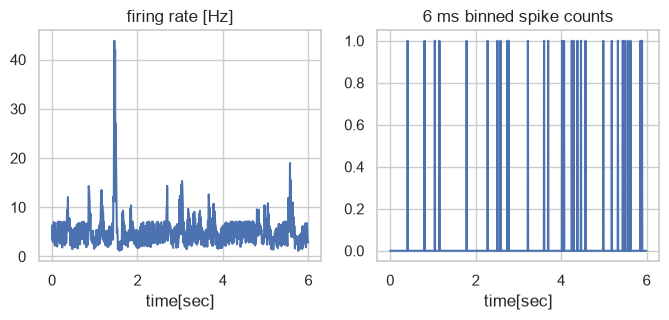

In [9]:
fig, ax = plt.subplots(figsize=(8, 3), ncols=2)

ax[0].plot(np.arange(1000) * time_bin, np.exp(log_mu0)[:1000] / time_bin)
ax[0].set_title("firing rate [Hz]")
ax[0].set_xlabel("time[sec]")

ax[1].plot(np.arange(1000) * time_bin, spike_counts[:1000])
ax[1].set_title(f"{time_bin * 1000:g} ms binned spike counts")
ax[1].set_xlabel("time[sec]")

## Fit the model

In [10]:
from pgam_jax import GAM

Each input's effect (i.e. the smooths or $f_i$) will be modeled using a basis.
The spatial and nuisance inputs use evaluation bases, where the basis is evaluated directly at the current input value. The temporal input uses a convolutional basis, where event history is filtered through a set of temporal basis functions.

Note that for evaluation bases explicitly specifying the range of their inputs using `bounds` is required.

They are then combined into a single additive basis:

In [11]:
spatial_basis = nmo.basis.BSplineEval(
    n_basis_funcs=17, order=4, bounds=(-5.0, 5.0), label="spatial"
)
nuisance_basis = nmo.basis.BSplineEval(
    n_basis_funcs=17, order=4, bounds=(-5.0, 5.0), label="nuisance"
)
temporal_basis = nmo.basis.BSplineConv(
    n_basis_funcs=12, window_size=251, label="temporal"
)

full_basis = spatial_basis + nuisance_basis + temporal_basis

Please note that `drop_conv_basis_col=True` is used for parity with the original PGAM implementation, but False (default in `pgam_jax`) would be more correct in theory.

Also, for small problems on CPU, using `scipy` (instead of `jaxopt`) is usually faster.

In [12]:
gam = GAM(
    full_basis,
    use_scipy=True,
    drop_conv_basis_col=True,
)

Fit the model:

In [13]:
gam.fit(
    (spatial_tsd, nuisance_tsd, events_tsd),
    spike_counts,
)

/Users/bagibence/freelance/2026/PGAM/code/pgam_jax-direct-reml/.venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(
/Users/bagibence/freelance/2026/PGAM/code/pgam_jax-direct-reml/.venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


## Evaluate the fit

We evaluate the spatial and nuisance smooths on values spanning their whole input range, while the temporal smooth is evaluated using an impulse.

In [14]:
n_test_points = 1000

spatial_input = np.linspace(-5, 5, n_test_points)

impulse_response_input = np.zeros(n_test_points)
impulse_response_input[n_test_points // 2] = 1

Plot the mean and a 95% pointwise confidence band:

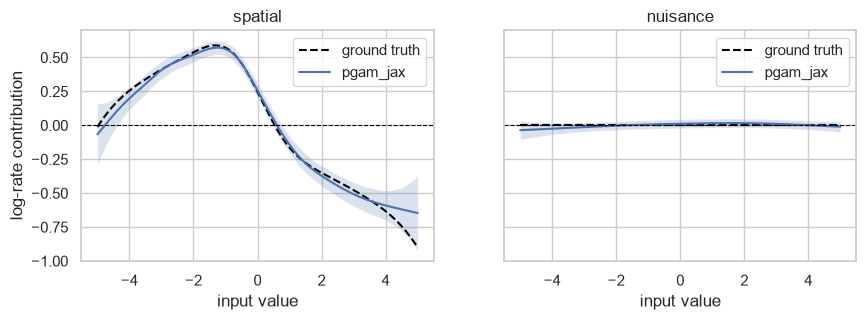

In [15]:
gam_spatial, gam_spatial_min, gam_spatial_max = gam.smooth_compute(
    spatial_input, "spatial"
)
gam_nuisance, gam_nuisance_min, gam_nuisance_max = gam.smooth_compute(
    spatial_input, "nuisance"
)

gt_spatial_response = spatial_resp_func(spatial_input)
centered_gt_spatial_response = gt_spatial_response - np.mean(gt_spatial_response)

gt_nuisance_response = np.zeros_like(spatial_input)

fig, ax = plt.subplots(figsize=(10, 3), ncols=2, sharey=True)
ax[0].plot(
    spatial_input,
    centered_gt_spatial_response,
    label="ground truth",
    color="black",
    ls="--",
)
ax[0].plot(spatial_input, gam_spatial, label="pgam_jax")
ax[0].fill_between(spatial_input, gam_spatial_min, gam_spatial_max, alpha=0.2)

ax[1].plot(
    spatial_input, gt_nuisance_response, label="ground truth", color="black", ls="--"
)
ax[1].plot(spatial_input, gam_nuisance, label="pgam_jax")
ax[1].fill_between(spatial_input, gam_nuisance_min, gam_nuisance_max, alpha=0.2)

ax[0].set_ylabel("log-rate contribution")
ax[0].set_title("spatial")
ax[1].set_title("nuisance")

for axi in ax:
    axi.axhline(0, color="black", lw=0.8, ls="--")
    axi.set_xlabel("input value")
    axi.legend()

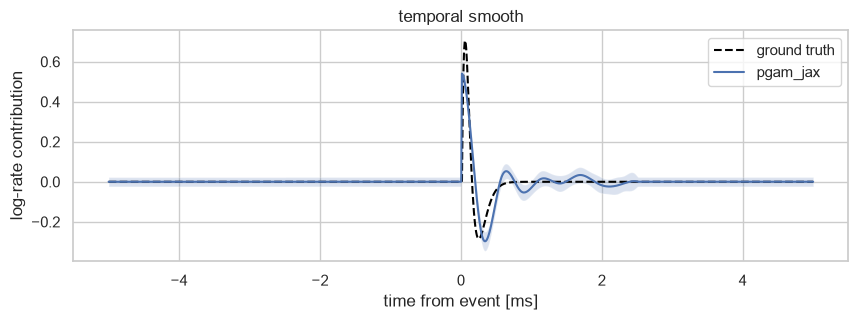

In [16]:
temporal_time_ms = (np.arange(n_test_points) - n_test_points // 2) * time_bin * 1000

gam_temporal, gam_temporal_min, gam_temporal_max = gam.smooth_compute(
    impulse_response_input, "temporal"
)

gt_temporal_response = temporal_resp_func(impulse_response_input)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(
    spatial_input, gt_temporal_response, label="ground truth", color="black", ls="--"
)
ax.plot(spatial_input, gam_temporal, label="pgam_jax")
ax.fill_between(spatial_input, gam_temporal_min, gam_temporal_max, alpha=0.2)

ax.set(
    xlabel="time from event [ms]",
    ylabel="log-rate contribution",
    title="temporal smooth",
)
ax.legend();

## Compare with original PGAM (Docker)

The example here closely mirrors the [original implementation's tutorial](https://github.com/balzaniedoardo/pgam/blob/main/pgam_tutorial.ipynb). 
We fit PGAM using that implementation as well and compare the results.

For a cleaner implementation comparison, the legacy fit below uses `optim_gam` on all samples, matching the `pgam_jax` fit above, rather than the tutorial's `fit_full_and_reduced` variable-selection workflow.

In [17]:
import shutil
import subprocess
import textwrap
from pathlib import Path

legacy_image = "edoardobalzani87/pgam:1.2"
legacy_artifact_dir = Path("artifacts/legacy_temporal")
legacy_artifact_dir.mkdir(parents=True, exist_ok=True)

legacy_case_path = legacy_artifact_dir / "temporal_case.npz"
legacy_worker_path = legacy_artifact_dir / "run_legacy_temporal.py"
legacy_output_path = legacy_artifact_dir / "legacy_temporal_results.npz"

np.savez_compressed(
    legacy_case_path,
    spatial_var=np.asarray(spatial_var),
    nuisance_var=np.asarray(nuisance_var),
    events=np.asarray(events),
    spike_counts=np.asarray(spike_counts),
    trial_ids=np.asarray(trial_ids),
    spatial_grid=np.asarray(spatial_input),
    time_bin=np.asarray(time_bin),
)

legacy_worker_path.write_text(textwrap.dedent(r"""
        import json
        import time

        import numpy as np
        import statsmodels.api as sm
        from PGAM.GAM_library import general_additive_model, smooths_handler

        case = np.load("/work/temporal_case.npz")
        spatial_var = case["spatial_var"]
        nuisance_var = case["nuisance_var"]
        events = case["events"]
        spike_counts = case["spike_counts"]
        trial_ids = case["trial_ids"]
        spatial_grid = case["spatial_grid"]
        time_bin = float(case["time_bin"])

        order = 4
        kernel_length = 500

        sm_handler = smooths_handler()
        # Exact knot convention from PGAM_Tutorial.ipynb cell 30.
        spatial_knots = np.hstack(([-5] * 3, np.linspace(-5, 5, 15), [5] * 3))
        sm_handler.add_smooth(
            "spatial",
            [spatial_var],
            knots=[spatial_knots],
            ord=order,
            is_temporal_kernel=False,
            trial_idx=trial_ids,
            is_cyclic=[False],
            penalty_type="der",
            der=2,
        )
        sm_handler.add_smooth(
            "nuisance",
            [nuisance_var],
            knots=[spatial_knots],
            ord=order,
            is_temporal_kernel=False,
            trial_idx=trial_ids,
            is_cyclic=[False],
            penalty_type="der",
            der=2,
        )
        sm_handler.add_smooth(
            "temporal",
            [events],
            knots=None,
            ord=order,
            is_temporal_kernel=True,
            trial_idx=trial_ids,
            is_cyclic=[False],
            penalty_type="der",
            der=2,
            knots_num=10,
            kernel_length=kernel_length,
            kernel_direction=1,
        )

        try:
            link = sm.genmod.families.links.log()
        except AttributeError:
            link = sm.genmod.families.links.Log()
        poisson_family = sm.genmod.families.family.Poisson(link=link)
        pgam = general_additive_model(
            sm_handler,
            sm_handler.smooths_var,
            spike_counts,
            poisson_family,
        )

        fit_t0 = time.perf_counter()
        fit = pgam.optim_gam(
            sm_handler.smooths_var,
            max_iter=10**2,
        )
        fit_s = time.perf_counter() - fit_t0

        exog = sm_handler.get_exog_mat_fast(sm_handler.smooths_var)[0]
        eta = np.clip(exog.dot(fit.beta), -30.0, 30.0)
        mu = np.exp(eta)

        spatial_response = fit.smooth_compute([spatial_grid], "spatial", perc=0.95)[0]
        nuisance_response = fit.smooth_compute([spatial_grid], "nuisance", perc=0.95)[0]

        dim_kern = fit.smooth_info["temporal"]["basis_kernel"].shape[0]
        impulse = np.zeros(dim_kern)
        impulse[(dim_kern - 1) // 2] = 1
        temporal_response, temporal_lo, temporal_hi = fit.smooth_compute(
            [impulse],
            "temporal",
            perc=0.95,
        )
        temporal_time = (np.arange(dim_kern) - (dim_kern - 1) // 2) * time_bin
        if fit.smooth_info["temporal"]["kernel_direction"] == 1:
            sel = temporal_time >= 0
            baseline = temporal_response[~sel][-1]
            temporal_response = temporal_response[sel] - baseline
            temporal_lo = temporal_lo[sel] - baseline
            temporal_hi = temporal_hi[sel] - baseline
            temporal_time = temporal_time[sel]

        np.savez_compressed(
            "/work/legacy_temporal_results.npz",
            beta=np.asarray(fit.beta),
            smooth_pen=np.asarray(fit.smooth_pen),
            mu=mu,
            eta=eta,
            spatial_response=spatial_response,
            nuisance_response=nuisance_response,
            temporal_response=temporal_response,
            temporal_lo=temporal_lo,
            temporal_hi=temporal_hi,
            temporal_time=temporal_time,
            fit_s=np.asarray(fit_s),
            var_list=np.asarray(fit.var_list),
        )

        print(
            json.dumps(
                {
                    "var_list": list(fit.var_list),
                    "beta_size": int(np.asarray(fit.beta).size),
                    "fit_s": fit_s,
                    "smooth_pen": np.asarray(fit.smooth_pen, dtype=float).tolist(),
                },
                indent=2,
            )
        )
        """))

if shutil.which("docker") is None:
    print("Docker is not available on this machine; skipping the legacy PGAM run.")
else:
    legacy_thread_env = (
        "OMP_NUM_THREADS=1",
        "OPENBLAS_NUM_THREADS=1",
        "MKL_NUM_THREADS=1",
    )
    command = [
        "docker",
        "run",
        "--rm",
        "-v",
        f"{legacy_artifact_dir.resolve()}:/work",
        "-w",
        "/work",
        *(flag for item in legacy_thread_env for flag in ("-e", item)),
        legacy_image,
        "python",
        "/work/run_legacy_temporal.py",
    ]
    print("Running legacy PGAM in Docker...")
    completed = subprocess.run(command, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout[-4000:])
    if completed.returncode != 0:
        print(completed.stderr[-4000:])
        print(f"Legacy PGAM Docker run failed with exit code {completed.returncode}.")
    else:
        print(f"Saved legacy PGAM output to {legacy_output_path}")

Running legacy PGAM in Docker...
{
  "var_list": [
    "spatial",
    "nuisance",
    "temporal"
  ],
  "beta_size": 44,
  "fit_s": 127.339668059,
  "smooth_pen": [
    77.74221108414062,
    0.45199409310242156,
    139605815.86944962,
    11406655.372441035,
    0.43008578650325746,
    0.06173478810169329
  ]
}

Saved legacy PGAM output to artifacts/legacy_temporal/legacy_temporal_results.npz


legacy fit time inside Docker: 127.34 s
corr(log fitted rate): 0.9956


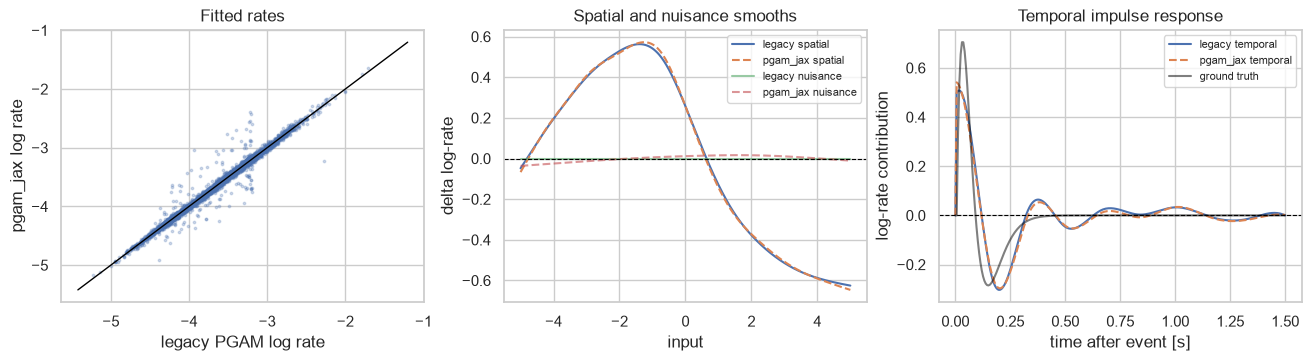

In [18]:
if not legacy_output_path.exists():
    print("Run the Docker cell above to create the legacy PGAM output first.")
else:
    legacy = np.load(legacy_output_path)

    jax_mu = np.asarray(gam.predict((spatial_var, nuisance_var, events)))
    legacy_mu = legacy["mu"]

    eps = np.finfo(float).tiny
    log_jax_mu = np.log(np.maximum(jax_mu, eps))
    log_legacy_mu = np.log(np.maximum(legacy_mu, eps))
    corr_log_rate = np.corrcoef(log_jax_mu, log_legacy_mu)[0, 1]

    print(f"legacy fit time inside Docker: {float(legacy['fit_s']):.2f} s")
    print(f"corr(log fitted rate): {corr_log_rate:.4f}")

    legacy_spatial = legacy["spatial_response"]
    legacy_nuisance = legacy["nuisance_response"]

    legacy_time = legacy["temporal_time"]
    legacy_temporal = legacy["temporal_response"]

    # Evaluate pgam_jax on a full-length impulse with enough pre-event context,
    # then slice the post-event segment to match the legacy causal response.
    jax_impulse_len = int(temporal_basis.window_size + legacy_time.shape[0])
    event_idx = int(temporal_basis.window_size - 1)
    jax_impulse = np.zeros(jax_impulse_len)
    jax_impulse[event_idx] = 1
    jax_zero = np.zeros_like(jax_impulse)
    jax_temporal = gam.smooth_compute(jax_impulse, "temporal")[0]
    jax_temporal = jax_temporal[event_idx : event_idx + legacy_time.shape[0]]

    temporal_ground_truth = temporal_resp_func(jax_impulse)
    temporal_ground_truth = temporal_ground_truth[
        event_idx : event_idx + legacy_time.shape[0]
    ]

    stride = max(1, len(log_jax_mu) // 5000)
    fig, ax = plt.subplots(figsize=(13, 3.5), ncols=3, constrained_layout=True)

    ax[0].scatter(log_legacy_mu[::stride], log_jax_mu[::stride], s=3, alpha=0.25)
    lo = min(log_legacy_mu.min(), log_jax_mu.min())
    hi = max(log_legacy_mu.max(), log_jax_mu.max())
    ax[0].plot([lo, hi], [lo, hi], color="black", lw=1)
    ax[0].set(
        xlabel="legacy PGAM log rate", ylabel="pgam_jax log rate", title="Fitted rates"
    )

    ax[1].plot(spatial_input, legacy_spatial, label="legacy spatial")
    ax[1].plot(spatial_input, gam_spatial, ls="--", label="pgam_jax spatial")
    ax[1].plot(spatial_input, legacy_nuisance, label="legacy nuisance", alpha=0.6)
    ax[1].plot(
        spatial_input, gam_nuisance, ls="--", label="pgam_jax nuisance", alpha=0.6
    )
    ax[1].axhline(0, color="black", lw=0.8, ls="--")
    ax[1].set(
        xlabel="input", ylabel="delta log-rate", title="Spatial and nuisance smooths"
    )
    ax[1].legend(fontsize=8)

    ax[2].plot(legacy_time, legacy_temporal, label="legacy temporal")
    ax[2].plot(legacy_time, jax_temporal, ls="--", label="pgam_jax temporal")
    ax[2].plot(
        legacy_time,
        temporal_ground_truth,
        color="black",
        alpha=0.5,
        label="ground truth",
    )
    ax[2].axhline(0, color="black", lw=0.8, ls="--")
    ax[2].set(
        xlabel="time after event [s]",
        ylabel="log-rate contribution",
        title="Temporal impulse response",
    )
    ax[2].legend(fontsize=8)